In [3]:
!pip install scikit-learn

In [1]:
import numpy as np

data = np.load("../96x96_tem_downsampled.npy")
data = data.squeeze()


print(type(data))
print(data.shape)

<class 'numpy.ndarray'>
(17266, 96, 96)


The dataset contains TEM images of many types - we want to extract crystalline/materials scans

In [2]:
from sklearn.preprocessing import StandardScaler

X = data.reshape(len(data), -1)
print(X.shape)

X = StandardScaler().fit_transform(X)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

(17266, 9216)


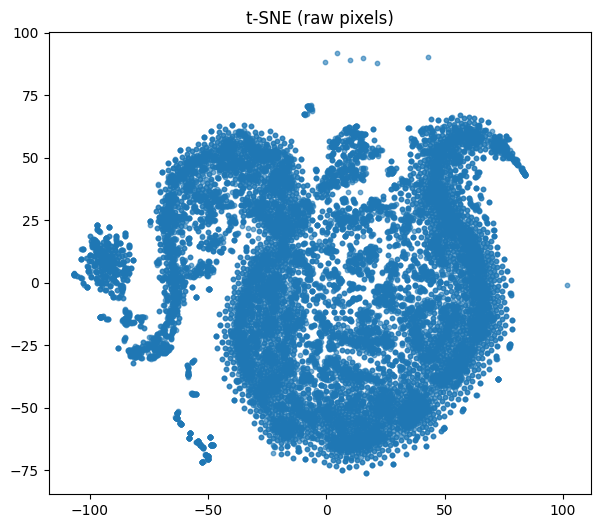

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_2d = tsne.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(X_2d[:,0], X_2d[:,1], s=10, alpha=0.6)
plt.title("t-SNE (raw pixels)")
plt.show()

In [4]:
x = X_2d[:, 0]
y = X_2d[:, 1]

# create bins
nx, ny = 5, 5   # 4x4 grid (adjust if needed)

x_bins = np.linspace(x.min(), x.max(), nx + 1)
y_bins = np.linspace(y.min(), y.max(), ny + 1)

In [5]:
selected = []

for i in range(nx):
    for j in range(ny):

        # bin region
        mask = (
            (x >= x_bins[i]) & (x < x_bins[i+1]) &
            (y >= y_bins[j]) & (y < y_bins[j+1])
        )

        idxs = np.where(mask)[0]

        if len(idxs) == 0:
            continue

        # pick representative (closest to bin center)
        cx = (x_bins[i] + x_bins[i+1]) / 2
        cy = (y_bins[j] + y_bins[j+1]) / 2

        d = (x[idxs] - cx)**2 + (y[idxs] - cy)**2
        selected.append(idxs[np.argmin(d)])

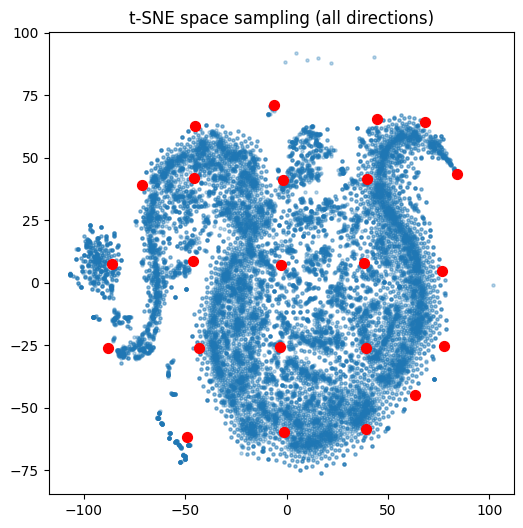

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(X_2d[:,0], X_2d[:,1], s=5, alpha=0.3)
plt.scatter(X_2d[selected,0], X_2d[selected,1], c='red', s=50)

plt.title("t-SNE space sampling (all directions)")
plt.show()

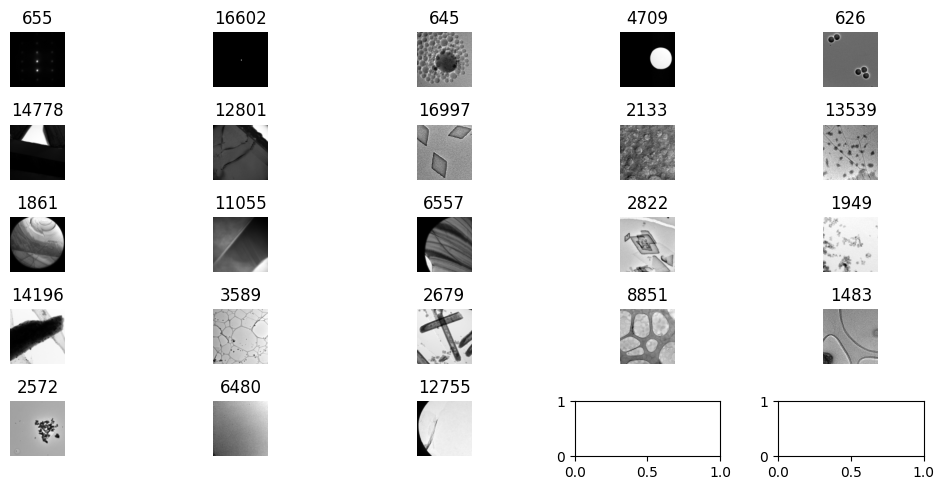

In [7]:
fig, axes = plt.subplots(5, 5, figsize=(10,5))

for ax, i in zip(axes.ravel(), selected):
    ax.imshow(data[i].squeeze(), cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

Exploring Alternate Dataset

In [4]:
!pip install pandas
!pip install os
!pip install requests
!pip install shutil
!pip install functools
!pip install tqdm

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached charset_normalizer-3.4.7-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached charset_normalizer-3.4.7-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (215 kB)
Using cached idna-3.18-py3-none-any.whl (65 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)
Using cached certifi-2026.5.20-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [requests]1/5 [idna]
ERROR: Could not find a version that satisfies the requirement

In [5]:
import pandas as pd
import os
import requests
import shutil
import functools
from tqdm import tqdm

The following code is taken from https://github.com/ScottLabUCB/HRTEM-Generalization/blob/main/dataset_creation/download_data_example.ipynb

In [6]:
# This is a routine that creates a pandas DataFrame with the data that meets the subset requirements
def subset_datafile(dataframe,subset_reqs):
    # dataframe is the pandas DataFrame with all of the metadata
    # subset_reqs is a list of tuples with the metadata requirements for the subset
    # The tuples either have 2 inputs (metadata, value) or 3 inputs (metadata, value, margin), and value can either be a string or quantitative number
    subset = dataframe
    subset_reqs_list = subset_reqs.copy()
    while len(subset_reqs_list)>0:
        listing = subset_reqs_list.pop()
        if len(listing)==2:
            heading = listing[0]
            value = listing[1]
            threshold = 1e-5
        else:
            heading = listing[0]
            value = listing[1]
            threshold = listing[2]
        if isinstance(value, str):
            subset = subset[subset[heading].isin([value])]
        else:
            diff = subset[heading]-value
            subset = subset[diff.abs()<threshold]
    return subset

In [7]:


#This function takes the subset and downloads the associated dm3 files and labels from NERSC
def download_images_NERSC(subset,download_location = 'hrtem_files', download_labels=True, label_ending='_label.png'):
    # Make folder in which images and labels will be downloaded 
    if not os.path.exists(download_location):
        os.mkdir(download_location)
    
    #NERSC URL (is constant unless project folder gets moved)
    nersc_url = 'https://portal.nersc.gov/project/m3795/hrtem-generalization/'
    
    # Tracker variables for how many imgs and labels are downloaded
    num_imgs = 0
    num_lbls = 0
    
    # For every file in the subset dataframe
    for i in range(subset.shape[0]):
        #Get the i-th file
        file = subset.iloc[i] 
        
        # if local folder for this file doesn't exist, make it
        if not os.path.exists(os.path.join(download_location,file['Folder'])):
            os.mkdir(os.path.join(download_location,file['Folder']))
        
        # define the locations
        download_url = nersc_url + '/' + file['Folder'] + '/' + file['File name']
        local_path = os.path.join(download_location,file['Folder'],file['File name'])
        
        # grab and download the data
        # only download if file is not already downloaded
        if not os.path.exists(local_path):
            response = requests.get(download_url, stream=True)
            
            # adding a progress bar
            file_size = int(response.headers.get('content-length',0))
            desc = "(Unknown total file size)" if file_size == 0 else ""
            response.raw.read = functools.partial(response.raw.read, decode_content=True)  # Decompress if needed
            
            if response.status_code == 200: #check if there's a file at the download_url provided
                with tqdm.wrapattr(response.raw, "read", total=file_size, desc=desc) as r_raw:
                    with open(local_path, 'wb') as output_file:
                        shutil.copyfileobj(r_raw, output_file)
                        del response
                num_imgs +=1
        
        # if you also want to download the corresponding label
        if download_labels == True:
            # make Labels folder in session folder, if not already there
            if not os.path.exists(os.path.join(download_location,file['Folder'],'Labels')):
                os.mkdir(os.path.join(download_location,file['Folder'],'Labels'))
            
            # Label locations
            lbl_name = file['File name'].split('.')[0]+label_ending
            lbl_download_url = nersc_url + '/' + file['Folder'] + '/Labels/' + lbl_name
            lbl_local_path = os.path.join(download_location,file['Folder'],'Labels',lbl_name)
            
            # Download label
            if not os.path.exists(lbl_local_path):
                response = requests.get(lbl_download_url, stream=True)
                
                # adding a progress bar
                file_size = int(response.headers.get('content-length',0))
                desc = "(Unknown total file size)" if file_size == 0 else ""
                response.raw.read = functools.partial(response.raw.read, decode_content=True)  # Decompress if needed
                
                if response.status_code == 200: #check if there's a file at the download_url provided
                    with tqdm.wrapattr(response.raw, "read", total=file_size, desc=desc) as r_raw:
                        with open(lbl_local_path, 'wb') as output_file:
                            shutil.copyfileobj(r_raw, output_file)
                            del response
                    num_lbls +=1
                    
    print(str(num_imgs)+' images and ' + str(num_lbls) + ' labels were downloaded')
    
    return None



In [9]:
spreadsheet_file = '../Dataset_metadata.csv'
file_list = pd.read_csv(spreadsheet_file)

subset_reqs = [('Material', 'Ag'), 
              ('Nanoparticle Size (nm)', 5),
              ('Dosage (e/A2)', 423, 20), 
              ('Pixel Scale (nm)', 0.02)]

subset_ag = subset_datafile(file_list,subset_reqs)
download_images_NERSC(subset_ag, download_location = 'hrtem_files', download_labels=True)

100%|██████████| 33.7k/33.7k [00:00<00:00, 177kB/s]
100%|██████████| 64.6M/64.6M [00:30<00:00, 2.22MB/s]
100%|██████████| 45.6k/45.6k [00:00<00:00, 114kB/s]
100%|██████████| 64.6M/64.6M [00:24<00:00, 2.79MB/s]
100%|██████████| 54.6k/54.6k [00:00<00:00, 166kB/s]
100%|██████████| 64.6M/64.6M [00:26<00:00, 2.55MB/s]
100%|██████████| 29.8k/29.8k [00:00<00:00, 146kB/s]
100%|██████████| 64.6M/64.6M [00:28<00:00, 2.36MB/s]
100%|██████████| 28.2k/28.2k [00:00<00:00, 140kB/s]
100%|██████████| 64.6M/64.6M [00:25<00:00, 2.60MB/s]
100%|██████████| 36.1k/36.1k [00:00<00:00, 185kB/s]
100%|██████████| 64.6M/64.6M [00:04<00:00, 14.3MB/s]
100%|██████████| 34.3k/34.3k [00:00<00:00, 179kB/s]
100%|██████████| 64.6M/64.6M [00:25<00:00, 2.68MB/s]
100%|██████████| 24.4k/24.4k [00:00<00:00, 122kB/s]
100%|██████████| 64.6M/64.6M [00:28<00:00, 2.41MB/s]
100%|██████████| 24.0k/24.0k [00:00<00:00, 124kB/s]
100%|██████████| 64.6M/64.6M [00:26<00:00, 2.52MB/s]
100%|██████████| 26.6k/26.6k [00:00<00:00, 167kB/s]
100

13 images and 14 labels were downloaded


In [16]:
!pip install ncempy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 20.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 MB 20.0 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ncempy]2m2/3 [ncempy]gin]


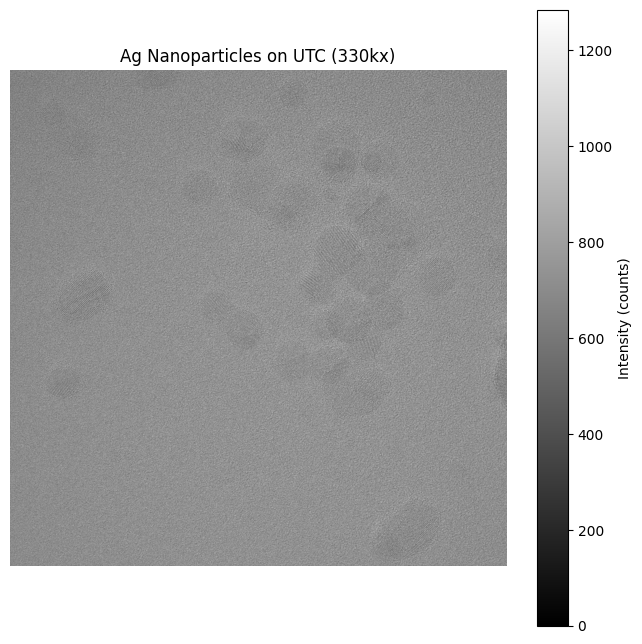

In [1]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt

file = Path("hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_02.dm3")

# Load the DM3 file
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']

plt.figure(figsize=(8, 8))
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.colorbar(label='Intensity (counts)')
plt.axis('off')  # Hides pixel coordinates for a cleaner look
plt.show()

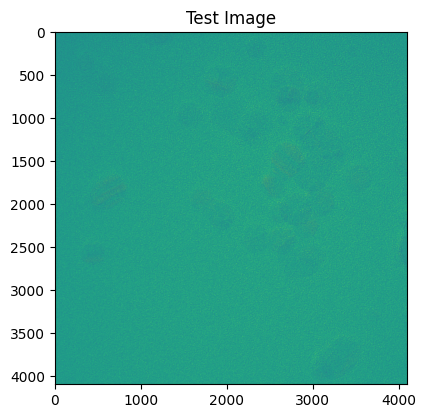

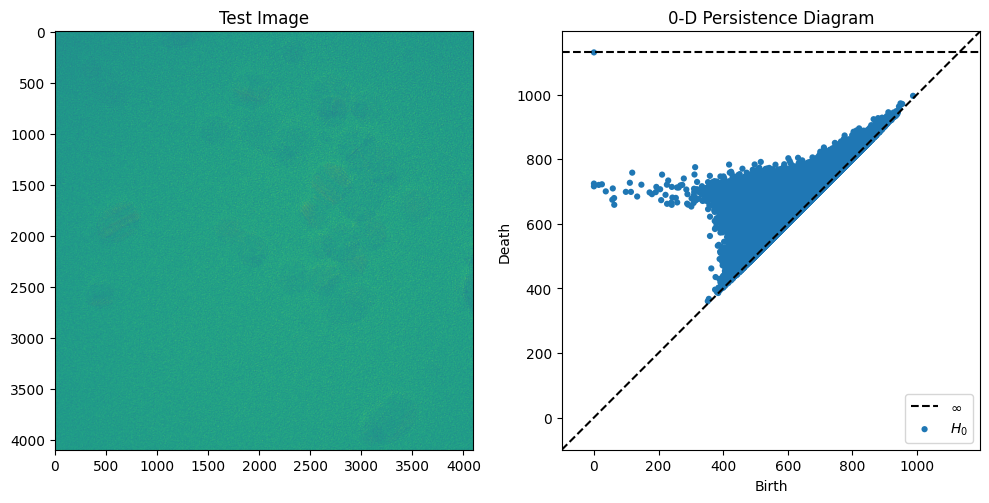

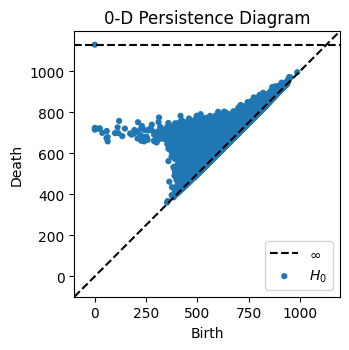

In [65]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img

dgm = lower_star_img(image_data)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image_data)
plt.title("Test Image")
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image_data)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()
plt.subplot(122)
plot_diagrams(dgm)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

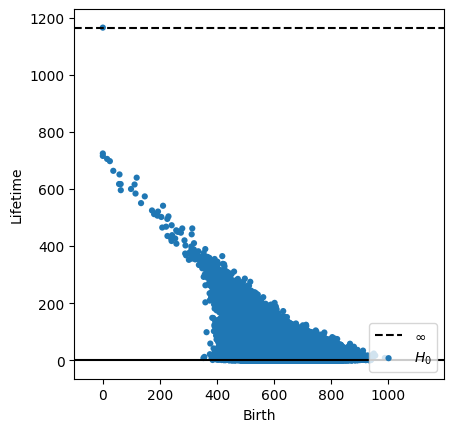

In [3]:
plot_diagrams(dgm, lifetime=True)
plt.show()

In [87]:
import cv2
import copy


def segment(threshold, image, dgm):

    pers = dgm[:,1] - dgm[:,0]

    idxs = np.where((pers >= threshold) &
                    (dgm[:,1] != np.inf))[0]

    h, w =image.shape

    segmentedpixels = np.zeros((h, w))
    enhanced_contours = []

    for i in idxs:

        birth = dgm[i, 0]
        death = dgm[i, 1]

        detected_mask = (image <= (birth)).astype(np.uint8)

        detected_mask *= 255
        

        kernel = np.ones((3,3), np.uint8)
        dilated_mask = cv2.dilate(detected_mask, kernel, iterations=2)

        # remove overlap
        non_overlapping_mask = copy.deepcopy(dilated_mask)
        non_overlapping_mask[segmentedpixels > 0] = 0

        segmentedpixels[non_overlapping_mask > 0] = 255

    return segmentedpixels

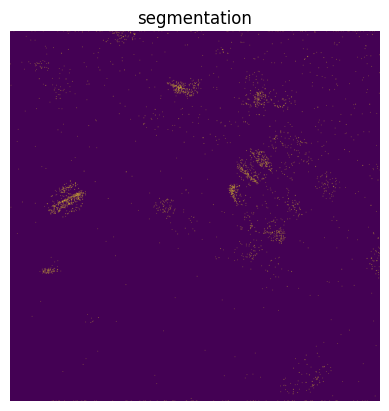

In [96]:
import numpy as np
import PIL

seg = segment(300, image_data, dgm)
plt.imshow(seg)
plt.title("segmentation")
plt.axis("off")
plt.show()

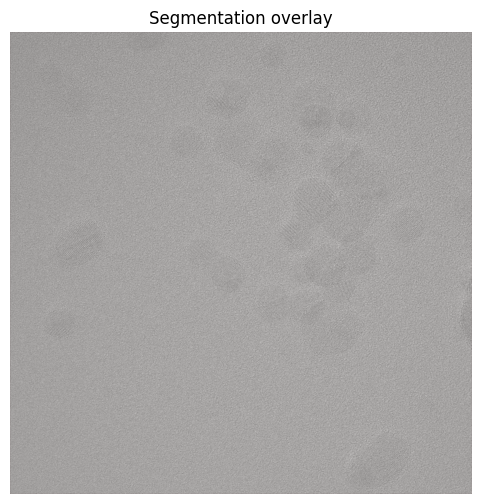

In [6]:
plt.figure(figsize=(6,6))

plt.imshow(image_data, cmap='gray')  

plt.imshow(seg, cmap='Reds', alpha=0.2)

plt.title("Segmentation overlay")
plt.axis("off")
plt.show()

Segmentation with image processing

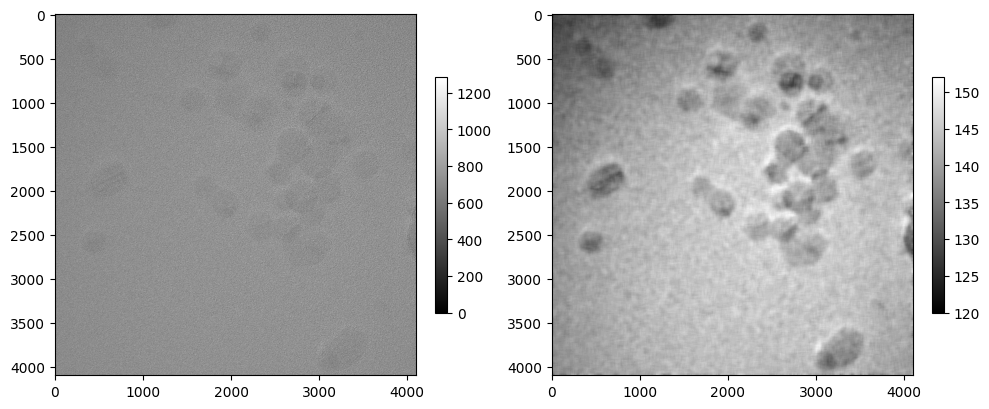

In [20]:
import numpy as np
import skimage.filters as filters
import cv2
from scipy import ndimage

smoothed_normalized = cv2.normalize(image_data, None, 0, 255, cv2.NORM_MINMAX)
smoothed_uint8 = smoothed_normalized.astype(np.uint8)
smoothed = cv2.medianBlur(smoothed_uint8, 61)

plt.figure(figsize=(10, 5))
plt.subplot(121)
im = plt.imshow(image_data, cmap="gray")
plt.colorbar(im, fraction=0.03)

plt.subplot(122)
im = plt.imshow(smoothed, cmap="gray")
plt.colorbar(im, fraction=0.03)

plt.tight_layout()
plt.show()

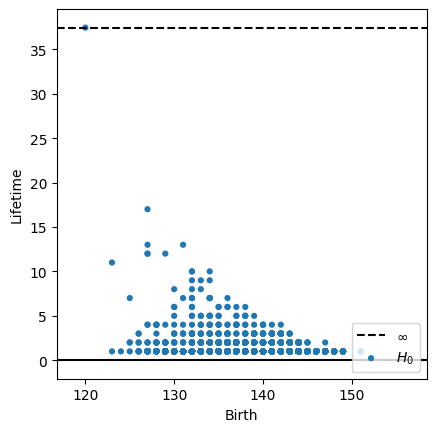

In [71]:
from persim import plot_diagrams
from ripser import lower_star_img

dgm_smoothed = lower_star_img(smoothed)
plot_diagrams(dgm_smoothed, lifetime=True)
plt.show()

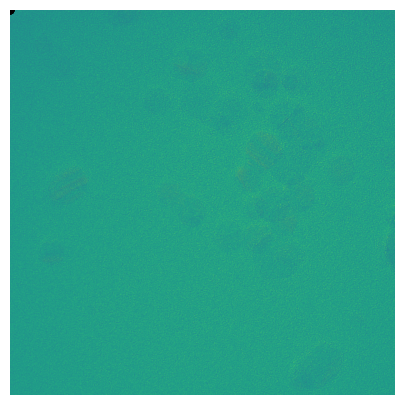

In [ ]:
thresh = 10
idxs = np.arange(dgm_smoothed.shape[0])
idxs = idxs[np.abs(dgm_smoothed[:, 1] - dgm_smoothed[:, 0]) > thresh]

plt.figure(figsize=(8, 5))
plt.imshow(image_data)

X, Y = np.meshgrid(np.arange(smoothed.shape[1]), np.arange(smoothed.shape[0]))
X = X.flatten()
Y = Y.flatten()
for idx in idxs:
    bidx = np.argmin(np.abs(smoothed + dgm[idx, 0]))
    plt.scatter(X[bidx], Y[bidx], 20, "k")
plt.axis("off")

plt.show()

120 152
[[255. 255. 255. ...   0.   0.   0.]
 [255. 255. 255. ...   0.   0.   0.]
 [255. 255. 255. ...   0.   0.   0.]
 ...
 [255. 255. 255. ...   0.   0.   0.]
 [255. 255. 255. ...   0.   0.   0.]
 [255. 255. 255. ...   0.   0.   0.]]


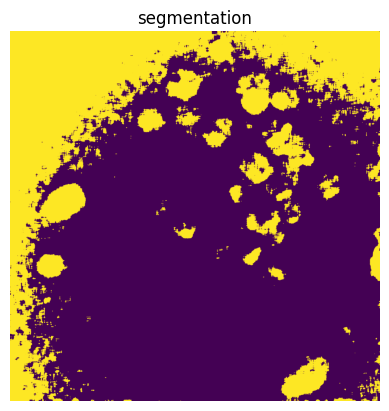

In [90]:
print(smoothed.min(), smoothed.max())

seg = segment(5, smoothed, dgm_smoothed)
print(seg)
plt.imshow(seg)
plt.title("segmentation")
plt.axis("off")
plt.show()

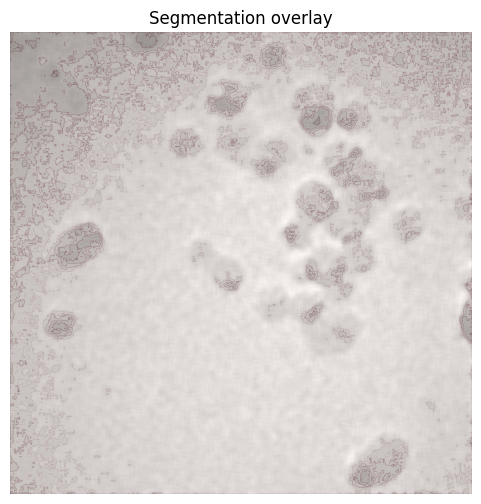

In [58]:
plt.figure(figsize=(6,6))

plt.imshow(smoothed, cmap='gray')  

plt.imshow(seg, cmap='Reds', alpha=0.5)

plt.title("Segmentation overlay")
plt.axis("off")
plt.show()